# Exploratory Data Analysis

- Dataset inspection
- Message length distribution
- Dialogue length distribution
- Same-user turn analysis
- Vocabulary exploration

Setup
---

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_colwidth', None)

df = pd.read_csv('./data/Ubuntu-dialogue-corpus/dialogueText.csv')

print("Shape:", df.shape)
df.head()

Shape: (1038324, 6)


,folder,dialogueID,date,from,to,text
0,3,126125.tsv,2008-04-23T14:55:00.000Z,bad_image,NaN,"Hello folks, please help me a bit with the following sentence: 'Order here your personal photos or videos.' - I think the only allowed version is 'Order your personal videos or photos here.', but I'm not sure, are you?"
1,3,126125.tsv,2008-04-23T14:56:00.000Z,bad_image,NaN,Did I choose a bad channel? I ask because you seem to be dumb like windows user
2,3,126125.tsv,2008-04-23T14:57:00.000Z,lordleemo,bad_image,the second sentence is better english and we are not dumb
3,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,Sock Puppe?t
4,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,WTF?


# 1. Message length distribution
- This helps justify the decision for MAX_LENGTH

count    1.038235e+06
mean     1.059930e+01
std      1.031706e+01
min      0.000000e+00
25%      4.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.070000e+02
Name: msg_length, dtype: float64


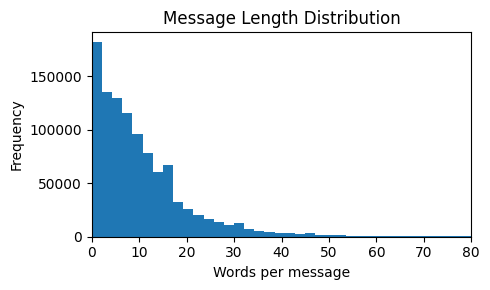

In [43]:
df = df.dropna(subset=['text'])

df['msg_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print(df['msg_length'].describe())

plt.figure(figsize=(5, 3))

plt.hist(df['msg_length'], bins=50)
plt.title("Message Length Distribution")
plt.xlabel("Words per message")
plt.ylabel("Frequency")
plt.xlim(0, 80)
plt.tight_layout()
os.makedirs("visualisations", exist_ok=True)
plt.savefig(
    "visualisations/message_length_distribution.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

# 2. Dialogue length distribution
- This supports our context window design

count    346108.000000
mean          2.999743
std           0.018384
min           1.000000
25%           3.000000
50%           3.000000
75%           3.000000
max           3.000000
dtype: float64


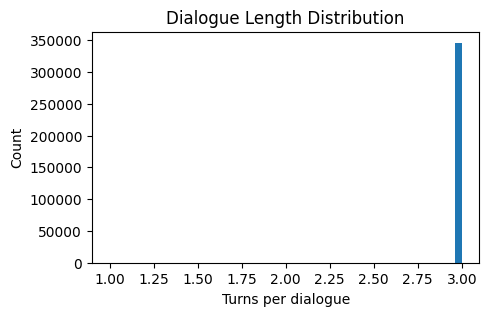

In [44]:
dialogue_lengths = df.groupby(['folder','dialogueID']).size()

print(dialogue_lengths.describe())

plt.figure(figsize=(5, 3))

plt.hist(dialogue_lengths, bins=50)
plt.title("Dialogue Length Distribution")
plt.xlabel("Turns per dialogue")
plt.ylabel("Count")
os.makedirs("visualisations", exist_ok=True)
plt.savefig(
    "visualisations/dialogue_length_distribution.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

# 3. Pair Quality Diagnostics
- How often does the same user appears in consecutive turns?
- This can indicate noisy pairing due to the presence of multi-user conversations.

In [45]:
same_user_pairs = 0
total_pairs = 0

grouped = df.groupby(['folder', 'dialogueID'])

for _, dialogue in grouped:
    dialogue = dialogue.reset_index(drop=True)

    for i in range(1, len(dialogue)):
        total_pairs += 1
        
        sender_prev = dialogue.loc[i-1, 'from']
        sender_curr = dialogue.loc[i, 'from']
        
        if sender_prev == sender_curr:
            same_user_pairs += 1

percentage = (same_user_pairs / total_pairs) * 100

print("Pair Quality Diagnostic")
print("----------------------")
print(f"Total consecutive turns: {total_pairs}")
print(f"Same-user turns: {same_user_pairs}")
print(f"Percentage same-user turns: {percentage:.2f}%")

Pair Quality Diagnostic
----------------------
Total consecutive turns: 692127
Same-user turns: 261225
Percentage same-user turns: 37.74%


# 4. Vocabulary Coverage Analysis
- How much of the text is still representable if we drop rare words?
- This helps justify the decision for MIN_TOKEN_FREQ

Vocabulary Coverage Analysis
----------------------------
min_freq=1
  vocab_size=369203
  coverage=100.00%
min_freq=2
  vocab_size=125137
  coverage=97.78%
min_freq=3
  vocab_size=76708
  coverage=96.90%
min_freq=5
  vocab_size=48031
  coverage=96.02%
min_freq=10
  vocab_size=28233
  coverage=94.86%


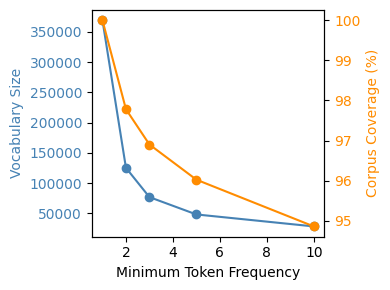

In [46]:
from collections import Counter

print("Vocabulary Coverage Analysis")
print("----------------------------")

counter = Counter()

for text in df['text'].dropna():
    tokens = text.lower().split()
    counter.update(tokens)

total_tokens = sum(counter.values())

for min_freq in [1,2,3,5,10]:
    kept_tokens = sum(c for w,c in counter.items() if c >= min_freq)
    vocab_size = sum(1 for w,c in counter.items() if c >= min_freq)

    print(f"min_freq={min_freq}")
    print(f"  vocab_size={vocab_size}")
    print(f"  coverage={(kept_tokens/total_tokens):.2%}")

# Recomputing for plotting 
min_freqs = [1, 2, 3, 5, 10]
vocab_sizes = []
coverages = []

for mf in min_freqs:
    kept_tokens = sum(c for w, c in counter.items() if c >= mf)
    vocab_size = sum(1 for w, c in counter.items() if c >= mf)
    coverage = kept_tokens / total_tokens
    vocab_sizes.append(vocab_size)
    coverages.append(coverage)

# Visualising
fig, ax1 = plt.subplots(figsize=(4,3))

ax1.plot(min_freqs, vocab_sizes, marker='o', color='steelblue')
ax1.set_xlabel("Minimum Token Frequency")
ax1.set_ylabel("Vocabulary Size", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(min_freqs, [c * 100 for c in coverages], marker='o', color='darkorange')
ax2.set_ylabel("Corpus Coverage (%)", color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Saving the figure
plt.tight_layout()
os.makedirs("visualisations", exist_ok=True)
plt.savefig(
    "visualisations/vocabulary_coverage.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

# 5. GloVe Coverage Analysis
- How much of our dataset vocabulary appears in pretrained embeddings?
- This helps assess their suitability.

GloVe Coverage Analysis
----------------------
Dataset vocab size: 369203
GloVe vocab size: 400000
Tokens covered by GloVe: 38051
GloVe coverage: 10.31%


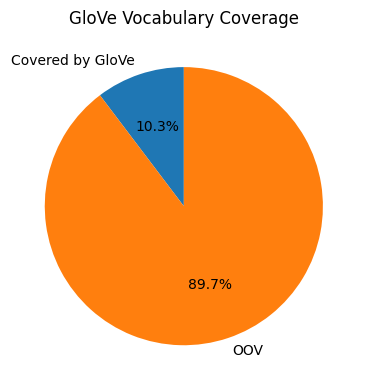

In [47]:
import numpy as np

print("GloVe Coverage Analysis")
print("----------------------")

# Loading GloVe vocabulary 
glove_path = "./data/glove/glove.6B.200d.txt"
glove_vocab = set()

with open(glove_path, "r", encoding="utf8") as f:
    for line in f:
        token = line.split()[0]
        glove_vocab.add(token)

dataset_vocab = set(counter.keys())

in_glove = dataset_vocab.intersection(glove_vocab)

coverage = len(in_glove) / len(dataset_vocab)

print(f"Dataset vocab size: {len(dataset_vocab)}")
print(f"GloVe vocab size: {len(glove_vocab)}")
print(f"Tokens covered by GloVe: {len(in_glove)}")
print(f"GloVe coverage: {coverage:.2%}")

covered = 0
not_covered = 0

for token in dataset_vocab:
    if token in glove_vocab:
        covered += 1
    else:
        not_covered += 1

labels = ["Covered by GloVe", "OOV"]
sizes = [covered, not_covered]

plt.figure(figsize=(6,4))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90)
plt.title("GloVe Vocabulary Coverage")
plt.tight_layout()
os.makedirs("visualisations", exist_ok=True)
plt.savefig(
    "visualisations/glove_coverage.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

# 6. Percentage of Rare Words
- This serves to diagnose vocabulary sparsity

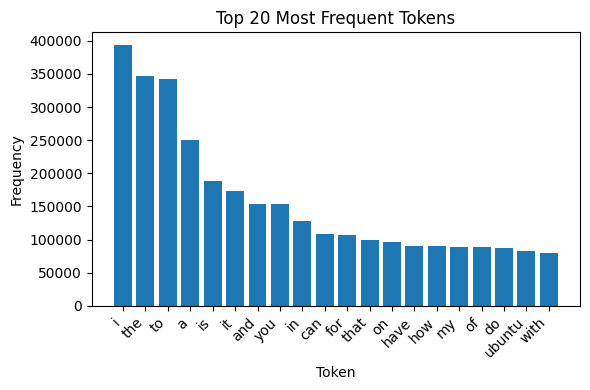

In [48]:
from collections import Counter
import matplotlib.pyplot as plt

counter = Counter()

for text in df['text'].dropna():
    tokens = text.lower().split()
    counter.update(tokens)

freqs = list(counter.values())

top_n = 20
most_common = counter.most_common(top_n)

words = [w for w, _ in most_common]
counts = [c for _, c in most_common]

plt.figure(figsize=(6,4))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Most Frequent Tokens")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.tight_layout()
os.makedirs("visualisations", exist_ok=True)
plt.savefig("visualisations/token_frequency_distribution.png", dpi=300)
plt.show()

# 7. Out of Vocabulary Tokens - Examples

In [49]:
oov_tokens = dataset_vocab - glove_vocab
print("Sample OOV tokens:")
print(list(oov_tokens)[:30])

Sample OOV tokens:
['black..i', 'mount**', 'buffer?', '10.10....', 'pxe..', 's*kdm', 'utf-8.', 'diable..', 'nasa)http://npp.gsfc.nasa.gov/images/viirs_4jan2012.jpg', '@varikoniemmi', 'know?...........', 'cntrl-alt-left_arrow/right_arrow.', 'cairo-doc', 'deffined', '2880x1800', 'examples).', 'ubuntu_newbie', '\ufeffhi!', 'capiira.so', 'packedge', "'drop", 'sloooow,', 'espeñol?', '(timezone)?', 'tibia920.tgz', 'say..', 'datetime?', 'h624)', 's.e.n.d,', 'urxtc?']


# 8. Coverage of Frequent Words
- If we keep only the top N words, how much of the corpus do they represent?
- It helps to select a reasonable vocabulary cutoff
- Assuming that a small number of words dominate, this can justify the decision for truncating vocabulary to 20k tokens

Coverage of top 5000 tokens: 63.26%
---------------------------
Top words kept  Corpus coverage
100             49.75%
500             69.29%
1000            76.38%
2000            82.46%
5000            88.45%


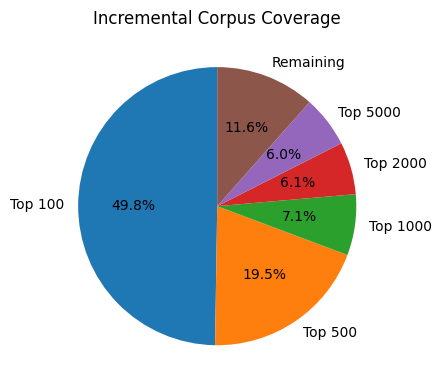

In [50]:
total_tokens = sum(counter.values())

top_tokens = [word for word, _ in counter.most_common(5000)]

covered = sum(1 for w in top_tokens if w in glove_vocab)

print(f"Coverage of top 5000 tokens: {covered/len(top_tokens):.2%}")
print(f"---------------------------")

sizes = [100, 500, 1000, 2000, 5000]

print(f"{'Top words kept':<15} {'Corpus coverage':<15}")

for k in sizes:
    top_k = counter.most_common(k)
    covered_tokens = sum(freq for _, freq in top_k)
    coverage = covered_tokens / total_tokens
    print(f"{k:<15} {coverage:.2%}")

sizes = [100, 500, 1000, 2000, 5000]

prev = 0
segments = []
labels = []

for k in sizes:
    top_k = counter.most_common(k)
    covered_tokens = sum(freq for _, freq in top_k)

    segment = covered_tokens - prev
    segments.append(segment)
    labels.append(f"Top {k}")

    prev = covered_tokens

# remaining
segments.append(total_tokens - prev)
labels.append("Remaining")

plt.figure(figsize=(6,4))
plt.pie(segments, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Incremental Corpus Coverage")

plt.tight_layout()
os.makedirs("visualisations", exist_ok=True)
plt.savefig("visualisations/corpus_coverage_by_top_tokens.png", dpi=300)
plt.show()

# 9. Vocabulary Coverage After Filtering < UNK >
- This should quantify how much information is lost when rare words become < UNK >

In [51]:
MIN_TOKEN_FREQ = 5

total_tokens = sum(counter.values())
kept_tokens = sum(count for word, count in counter.items() if count >= MIN_TOKEN_FREQ)

print("Token coverage after filtering:")
print(f"Coverage: {kept_tokens / total_tokens:.2%}")

Token coverage after filtering:
Coverage: 96.02%


# 10. Visualising Decoder Attention (draft) 
- Attention scores are normalised using a softmax function to produce attention weights. We're visualising this as a heatmap to highlight which input tokens the model attends to when generating each output token:
- Columns = the x-axis to represent input tokens processed by the encoder
- Rows = y-axis to represent tokens generated by the decoder at each timestep
- Colour intensity = how much attention the model assigned to an input token when generating an output token.

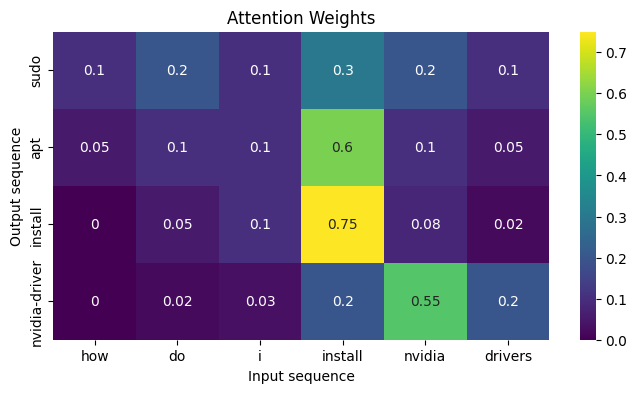

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Example input and output tokens
input_tokens = ["how", "do", "i", "install", "nvidia", "drivers"]
output_tokens = ["sudo", "apt", "install", "nvidia-driver"]

# Example attention matrix (rows = output, columns = input)
attention_matrix = np.array([
    [0.10, 0.20, 0.10, 0.30, 0.20, 0.10],  # attention when generating "sudo"
    [0.05, 0.10, 0.10, 0.60, 0.10, 0.05],  # attention when generating "apt"
    [0.00, 0.05, 0.10, 0.75, 0.08, 0.02],  # attention when generating "install"
    [0.00, 0.02, 0.03, 0.20, 0.55, 0.20]   # attention when generating "nvidia-driver"
])

plt.figure(figsize=(8,4))

sns.heatmap(
    attention_matrix,
    xticklabels=input_tokens,
    yticklabels=output_tokens,
    cmap="viridis",
    annot=True)

plt.xlabel("Input sequence")
plt.ylabel("Output sequence")
plt.title("Attention Weights")
plt.show()